In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\extended_flower_morphometrics.csv")

In [3]:
df=data.copy()

In [4]:
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
0,4.317614,3.028292,6.092543,3.166156,5.063025,63.558150,55.913100,886.568622,Rose
1,5.531122,3.887679,5.497682,2.374855,4.656235,52.368783,26.383116,247.206553,Iris Versicolor
2,5.908407,2.576321,6.264473,1.785481,5.893707,36.056153,61.562376,1197.921681,Orchid
3,6.855284,2.764075,4.606390,1.175031,4.854951,55.623467,38.671083,940.401196,Iris Versicolor
4,5.412124,3.691987,1.800383,0.221225,2.528513,60.218904,34.674831,679.473136,Iris Setosa


In [5]:
df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,6.494801,3.701722,5.660341,2.339627,6.756894,53.202820,45.769422,568.676301
std,2.389844,1.219015,3.769632,1.761005,4.301134,13.891707,10.579623,277.763702
min,1.314396,-0.681257,-0.040491,-1.097662,-1.357669,-0.531327,2.766288,-562.840890
25%,4.976431,2.955377,3.371251,1.137561,3.772243,43.519517,38.443302,374.074507
50%,5.732968,3.406310,4.901882,2.118828,5.459812,52.465437,45.348677,552.110497
75%,6.973427,4.003575,6.466747,3.107515,7.910897,62.153948,52.640398,749.846888
max,18.797057,11.130567,24.222782,10.444469,28.019564,116.494596,98.869354,1954.432880


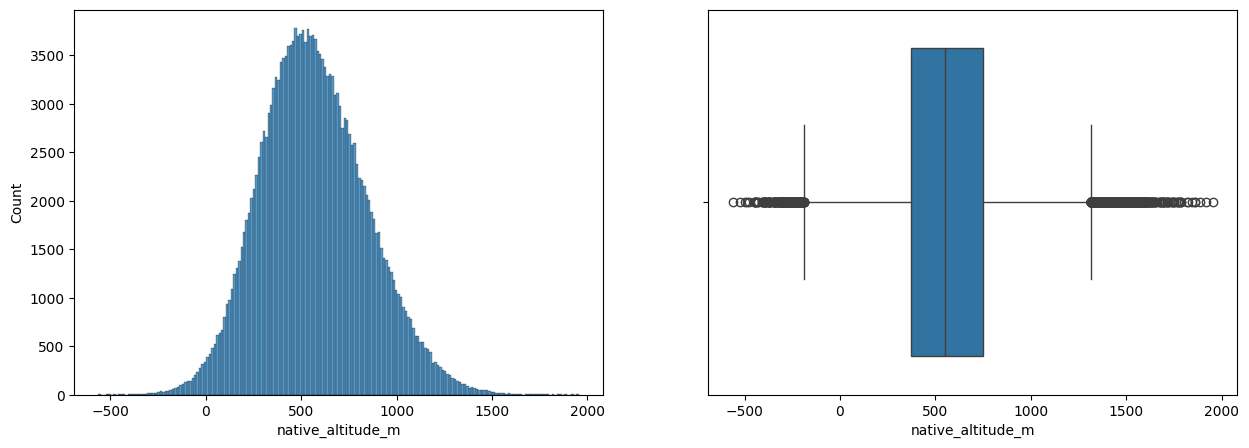

In [6]:

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(x="native_altitude_m",data=df)
plt.subplot(1,2,2)
sns.boxplot(x="native_altitude_m",data=df)
plt.show()

In [7]:
df["species"].value_counts()

species
Rose               40000
Iris Versicolor    40000
Orchid             40000
Iris Setosa        40000
Sunflower          40000
Name: count, dtype: int64

In [8]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
#sns.pairplot(data=df,hue="species")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(max_iter=1000)

In [12]:
lg.fit(x_train,y_train)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
x_test

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
119737,10.059837,5.389680,9.076074,3.594354,16.712364,58.116433,44.246086,499.691086
72272,4.355723,2.839801,5.321844,3.733462,4.077434,51.381892,49.224692,1062.496068
158154,4.825941,3.303383,4.179553,2.131481,4.981118,53.919414,42.533879,1040.104821
65426,5.753130,3.682849,5.615437,1.393666,7.179669,56.690537,49.558729,668.056266
30074,8.721523,5.399467,10.208708,4.892941,9.768504,51.510600,74.608119,328.349583
...,...,...,...,...,...,...,...,...
4174,5.146004,3.228467,1.438340,0.308106,2.796993,42.898127,33.970413,450.219293
91537,4.984668,3.862052,1.748991,0.290535,1.586392,39.385831,23.304827,551.709029
156449,12.453620,5.416711,12.908285,5.460656,16.582271,61.457446,64.656210,250.315757
184376,4.719934,3.349905,4.271692,1.875968,7.832408,41.253452,53.622573,724.254814


In [14]:
y_test

119737          Sunflower
72272              Orchid
158154    Iris Versicolor
65426                Rose
30074           Sunflower
               ...       
4174          Iris Setosa
91537         Iris Setosa
156449          Sunflower
184376             Orchid
6584      Iris Versicolor
Name: species, Length: 40000, dtype: object

In [15]:
lg.predict([[10.059837,5.389680,9.076074,3.594354,16.712364,58.116433,44.246086,499.691086]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Sunflower'], dtype=object)

In [16]:
print(lg.score(x_test,y_test),lg.score(x_train,y_train))

0.781925 0.77640625


In [17]:
from sklearn.metrics import confusion_matrix
cf=confusion_matrix(y_test,lg.predict(x_test))

In [18]:
df['species'].unique()

array(['Rose', 'Iris Versicolor', 'Orchid', 'Iris Setosa', 'Sunflower'],
      dtype=object)

In [19]:

'''sns.heatmap(cf,annot=True,fmt="d",
            xticklabels=['Rose', 'Iris Versicolor', 'Orchid', 'Iris Setosa', 'Sunflower'],
            yticklabels=['Rose', 'Iris Versicolor', 'Orchid', 'Iris Setosa', 'Sunflower'])
plt.xticks(rotation=30)
plt.yticks(rotation=30)
plt.show()'''

'sns.heatmap(cf,annot=True,fmt="d",\n            xticklabels=[\'Rose\', \'Iris Versicolor\', \'Orchid\', \'Iris Setosa\', \'Sunflower\'],\n            yticklabels=[\'Rose\', \'Iris Versicolor\', \'Orchid\', \'Iris Setosa\', \'Sunflower\'])\nplt.xticks(rotation=30)\nplt.yticks(rotation=30)\nplt.show()'

In [53]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dc=DecisionTreeClassifier(max_depth=11,criterion='entropy')
dc.fit(x_train,y_train)
print(dc.score(x_test,y_test),dc.score(x_train,y_train))

0.795175 0.80630625


In [21]:
'''for i in range(1,21):
    dc=DecisionTreeClassifier(max_depth=i,criterion="gini")
    dc.fit(x_train,y_train)
    print(dc.score(x_test,y_test),dc.score(x_train,y_train),i)'''

'for i in range(1,21):\n    dc=DecisionTreeClassifier(max_depth=i,criterion="gini")\n    dc.fit(x_train,y_train)\n    print(dc.score(x_test,y_test),dc.score(x_train,y_train),i)'

In [22]:

'''plt.figure(figsize=(15,15))
plot_tree(dc,filled=True,
    feature_names=x.columns,
    class_names=dc.classes_,
    rounded=True,
    fontsize=10)
plt.show()'''

'plt.figure(figsize=(15,15))\nplot_tree(dc,filled=True,\n    feature_names=x.columns,\n    class_names=dc.classes_,\n    rounded=True,\n    fontsize=10)\nplt.show()'

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)
print(knn.score(x_test,y_test),knn.score(x_train,y_train),)

0.70755 0.79956875


In [24]:
'''for i in range (1,21):
    knn=KNeighborsClassifier(n_neighbors=i,weights='distance')
    knn.fit(x_train,y_train)
    print(knn.score(x_test,y_test),knn.score(x_train,y_train),i)'''

"for i in range (1,21):\n    knn=KNeighborsClassifier(n_neighbors=i,weights='distance')\n    knn.fit(x_train,y_train)\n    print(knn.score(x_test,y_test),knn.score(x_train,y_train),i)"

In [25]:
from sklearn.svm import SVC
sv=SVC()


In [27]:
'''sv.fit(x_train,y_train)
print(sv.score(x_test,y_test),sv.score(x_train,y_train))'''

'sv.fit(x_train,y_train)\nprint(sv.score(x_test,y_test),sv.score(x_train,y_train))'

In [29]:
from sklearn.naive_bayes import BernoulliNB,MultinomialNB,GaussianNB
gs=GaussianNB()
ml=MultinomialNB()
br=BernoulliNB()


In [34]:
br.fit(x_train,y_train)
print(br.score(x_test,y_test),br.score(x_train,y_train))

0.21625 0.22293125


gs.fit(x_train,y_train)
print(gs.score(x_test,y_test),gs.score(x_train,y_train))

In [39]:
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
rd=RandomForestClassifier(n_estimators=10)
bg=BaggingClassifier()

In [40]:
rd.fit(x_train,y_train)
print(rd.score(x_test,y_test),rd.score(x_train,y_train))

0.80325 0.9917375


In [41]:
bg.fit(x_train,y_train)
print(bg.score(x_test,y_test),bg.score(x_train,y_train))

0.801425 0.99081875


In [49]:
list=[("lg",LogisticRegression()),("dc",DecisionTreeClassifier()),("gs",GaussianNB())]

In [50]:
from sklearn.ensemble import VotingClassifier
vt=VotingClassifier(list)

In [51]:
vt.fit(x_train,y_train)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimators,"[('lg', ...), ('dc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [52]:
print(vt.score(x_test,y_test),vt.score(x_train,y_train))

0.807125 0.87228125


In [55]:
pre={"lg":lg.predict(x_test),"dc":dc.predict(x_test),"gs":gs.predict(x_test),"vt":vt.predict(x_test),"actual":y_test}

In [56]:
prediction=pd.DataFrame(pre)

In [57]:
prediction

,lg,dc,gs,vt,actual
119737,Sunflower,Sunflower,Sunflower,Sunflower,Sunflower
72272,Orchid,Orchid,Orchid,Orchid,Orchid
158154,Orchid,Orchid,Iris Versicolor,Iris Versicolor,Iris Versicolor
65426,Iris Versicolor,Rose,Rose,Iris Versicolor,Rose
30074,Sunflower,Sunflower,Sunflower,Sunflower,Sunflower
...,...,...,...,...,...
4174,Iris Setosa,Iris Setosa,Iris Setosa,Iris Setosa,Iris Setosa
91537,Iris Setosa,Iris Setosa,Iris Setosa,Iris Setosa,Iris Setosa
156449,Sunflower,Sunflower,Sunflower,Sunflower,Sunflower
184376,Rose,Orchid,Iris Versicolor,Iris Versicolor,Orchid


In [60]:
print(prediction["lg"].value_counts(),prediction["dc"].value_counts(),prediction["gs"].value_counts(),prediction["vt"].value_counts())

lg
Rose               8641
Sunflower          8372
Iris Setosa        8181
Orchid             7822
Iris Versicolor    6984
Name: count, dtype: int64 dc
Iris Versicolor    8774
Sunflower          8118
Iris Setosa        8052
Orchid             7598
Rose               7458
Name: count, dtype: int64 gs
Iris Versicolor    8582
Sunflower          8124
Iris Setosa        8068
Rose               7855
Orchid             7371
Name: count, dtype: int64 vt
Iris Versicolor    8546
Iris Setosa        8185
Sunflower          8117
Rose               7838
Orchid             7314
Name: count, dtype: int64


In [61]:
prediction["actual"].value_counts()


actual
Sunflower          8126
Rose               8081
Iris Setosa        8062
Iris Versicolor    7960
Orchid             7771
Name: count, dtype: int64